In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv("/content/final_dataset.csv")

In [ ]:
df

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm
...,...,...
106350,i used to feel strongly about how much i hated...,hate
106351,i feel like i just got a spirit booster this r...,surprise
106352,i could come up with is that i was really feel...,anger
106353,i find it really it helps to have an outfit of...,relief


In [ ]:
df.head(5)

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [ ]:
df['text'] = df['text'].str.lower()
display(df.head())

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError
from nltk.tokenize import word_tokenize

df['tokens'] = df['text'].apply(word_tokenize)

print("Tokenized text for the first 5 samples:")
for i in range(5):
    print(f"Sample {i+1}: {df['tokens'].iloc[i]}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tokenized text for the first 5 samples:
Sample 1: ['i', 'feel', 'rather', 'funny', 'ending', 'with', 'so', 'many', 'dupes', 'while', 'i', 'always', 'prefer', 'originals']
Sample 2: ['i', 'feel', 'surprised', 'by', 'the', 'result']
Sample 3: ['i', 'am', 'officially', 'feeling', 'festive']
Sample 4: ['i', 'suddenly', 'found', 'myself', 'standing', 'before', 'this', 'woman', 'dressed', 'like', 'a', 'priestess', 'with', 'white', 'robes', 'and', 'egyptian', 'jewellery', 'long', 'black', 'hair', 'and', 'realized', 'that', 'i', 'was', 'feeling', 'amorous', 'and', 'passionate', 'and', 'noticed', 'to', 'my', 'surprise', 'that', 'my', 'breath', 'was', 'green', 'i', 'was', 'breathing', 'out', 'clouds', 'of', 'green', 'energy']
Sample 5: ['i', 'look', 'at', 'the', 'meager', 'pile', 'of', 'food', 'i', 'purchased', 'for', 'the', 'week', 'i', 'am', 'feeling', 'pretty', 'apprehensive']


### 4. Stopword Removal

Now, let's remove common English stopwords from our tokenized text to focus on more meaningful words.

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

print("Tokenized text before and after stopword removal for the first 5 samples:")
for i in range(5):
    print(f"\nSample {i+1}:")
    print(f"  Original Tokens: {df['tokens'].iloc[i]}")
    print(f"  Tokens (No Stopwords): {df['tokens_no_stopwords'].iloc[i]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tokenized text before and after stopword removal for the first 5 samples:

Sample 1:
  Original Tokens: ['i', 'feel', 'rather', 'funny', 'ending', 'with', 'so', 'many', 'dupes', 'while', 'i', 'always', 'prefer', 'originals']
  Tokens (No Stopwords): ['feel', 'rather', 'funny', 'ending', 'many', 'dupes', 'always', 'prefer', 'originals']

Sample 2:
  Original Tokens: ['i', 'feel', 'surprised', 'by', 'the', 'result']
  Tokens (No Stopwords): ['feel', 'surprised', 'result']

Sample 3:
  Original Tokens: ['i', 'am', 'officially', 'feeling', 'festive']
  Tokens (No Stopwords): ['officially', 'feeling', 'festive']

Sample 4:
  Original Tokens: ['i', 'suddenly', 'found', 'myself', 'standing', 'before', 'this', 'woman', 'dressed', 'like', 'a', 'priestess', 'with', 'white', 'robes', 'and', 'egyptian', 'jewellery', 'long', 'black', 'hair', 'and', 'realized', 'that', 'i', 'was', 'feeling', 'amorous', 'and', 'passionate', 'and', 'noticed', 'to', 'my', 'surprise', 'that', 'my', 'breath', 'was', 'gre

### 5. Stemming

Now, let's apply a Porter Stemmer to reduce words to their root or base form. This helps in normalizing words and reducing vocabulary size.

In [ ]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['tokens_stemmed'] = df['tokens_no_stopwords'].apply(apply_stemming)

print("Tokenized text after stemming for the first 10 samples:")
for i in range(10):
    print(f"\nSample {i+1}:")
    print(f"  Original Tokens (No Stopwords): {df['tokens_no_stopwords'].iloc[i]}")
    print(f"  Stemmed Tokens: {df['tokens_stemmed'].iloc[i]}")

Tokenized text after stemming for the first 10 samples:

Sample 1:
  Original Tokens (No Stopwords): ['feel', 'rather', 'funny', 'ending', 'many', 'dupes', 'always', 'prefer', 'originals']
  Stemmed Tokens: ['feel', 'rather', 'funni', 'end', 'mani', 'dupe', 'alway', 'prefer', 'origin']

Sample 2:
  Original Tokens (No Stopwords): ['feel', 'surprised', 'result']
  Stemmed Tokens: ['feel', 'surpris', 'result']

Sample 3:
  Original Tokens (No Stopwords): ['officially', 'feeling', 'festive']
  Stemmed Tokens: ['offici', 'feel', 'festiv']

Sample 4:
  Original Tokens (No Stopwords): ['suddenly', 'found', 'standing', 'woman', 'dressed', 'like', 'priestess', 'white', 'robes', 'egyptian', 'jewellery', 'long', 'black', 'hair', 'realized', 'feeling', 'amorous', 'passionate', 'noticed', 'surprise', 'breath', 'green', 'breathing', 'clouds', 'green', 'energy']
  Stemmed Tokens: ['suddenli', 'found', 'stand', 'woman', 'dress', 'like', 'priestess', 'white', 'robe', 'egyptian', 'jewelleri', 'long', '

### 6. Lemmatization

Lemmatization is similar to stemming but aims to return the base or dictionary form of a word (the lemma), which is a linguistically valid word. Let's apply it and compare with the stemming results.

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet (OMW) data

lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens_lemmatized'] = df['tokens_no_stopwords'].apply(apply_lemmatization)

print("Comparison of Stemmed vs. Lemmatized text for the first 10 samples:")
for i in range(10):
    print(f"\nSample {i+1}:")
    print(f"  Original Tokens (No Stopwords): {df['tokens_no_stopwords'].iloc[i]}")
    print(f"  Stemmed Tokens: {df['tokens_stemmed'].iloc[i]}")
    print(f"  Lemmatized Tokens: {df['tokens_lemmatized'].iloc[i]}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Comparison of Stemmed vs. Lemmatized text for the first 10 samples:

Sample 1:
  Original Tokens (No Stopwords): ['feel', 'rather', 'funny', 'ending', 'many', 'dupes', 'always', 'prefer', 'originals']
  Stemmed Tokens: ['feel', 'rather', 'funni', 'end', 'mani', 'dupe', 'alway', 'prefer', 'origin']
  Lemmatized Tokens: ['feel', 'rather', 'funny', 'ending', 'many', 'dupe', 'always', 'prefer', 'original']

Sample 2:
  Original Tokens (No Stopwords): ['feel', 'surprised', 'result']
  Stemmed Tokens: ['feel', 'surpris', 'result']
  Lemmatized Tokens: ['feel', 'surprised', 'result']

Sample 3:
  Original Tokens (No Stopwords): ['officially', 'feeling', 'festive']
  Stemmed Tokens: ['offici', 'feel', 'festiv']
  Lemmatized Tokens: ['officially', 'feeling', 'festive']

Sample 4:
  Original Tokens (No Stopwords): ['suddenly', 'found', 'standing', 'woman', 'dressed', 'like', 'priestess', 'white', 'robes', 'egyptian', 'jewellery', 'long', 'black', 'hair', 'realized', 'feeling', 'amorous', 'passio

### 7. Bag of Words (BoW)

Now, let's implement the Bag of Words model using `CountVectorizer`. This will convert our text data into numerical feature vectors.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert list of tokens back to string for CountVectorizer
df['text_lemmatized'] = df['tokens_lemmatized'].apply(lambda x: ' '.join(x))

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the lemmatized text
bow_matrix = vectorizer.fit_transform(df['text_lemmatized'])

print("\n--- Vocabulary (Feature Names) ---")
# Display a sample of vocabulary (e.g., first 20 words)
print(vectorizer.get_feature_names_out()[:20])
print(f"Total vocabulary size: {len(vectorizer.get_feature_names_out())}")

print("\n--- Bag of Words Matrix (Sparse Matrix) ---")
# Display the sparse matrix (e.g., for the first 5 documents)
print(bow_matrix[:5].toarray())

print("\n--- Shape of the Bag of Words Matrix ---")
print(bow_matrix.shape)

# Adding a sample of the transformed data to the DataFrame for inspection
df_bow_sample = pd.DataFrame(bow_matrix[:5].toarray(), columns=vectorizer.get_feature_names_out())
print("\n--- Sample of BoW Matrix as DataFrame ---")
display(df_bow_sample.head())


--- Vocabulary (Feature Names) ---
['00' '000' '000calories' '000shs' '000th' '000ème' '00pm' '01'
 '0235299130' '04' '05' '0512' '06' '08' '09' '0_o' '0l' '0ntworpen' '0w'
 '10']
Total vocabulary size: 39814

--- Bag of Words Matrix (Sparse Matrix) ---
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

--- Shape of the Bag of Words Matrix ---
(106355, 39814)

--- Sample of BoW Matrix as DataFrame ---


,00,000,000calories,000shs,000th,000ème,00pm,01,0235299130,04,...,งก,งป,งย,นก,นใน,ยอมตายไปส,หญ,เขาจะเผาม,ℕoíʀ,ㄒʜℰℳℰ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 8. TF-IDF Vectorization

Now, let's implement the TF-IDF (Term Frequency-Inverse Document Frequency) model using `TfidfVectorizer`. This will give us a numerical representation of our text that reflects the importance of words in a document relative to the entire corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the lemmatized text
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_lemmatized'])

print("\n--- Vocabulary (Feature Names) --- ")
# Display a sample of vocabulary (e.g., first 20 words)
print(tfidf_vectorizer.get_feature_names_out()[:20])
print(f"Total vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")

print("\n--- TF-IDF Matrix (Sparse Matrix) ---")
# Display the sparse matrix (e.g., for the first 5 documents)
print(tfidf_matrix[:5].toarray())

print("\n--- Shape of the TF-IDF Matrix ---")
print(tfidf_matrix.shape)

# Adding a sample of the transformed data to the DataFrame for inspection
df_tfidf_sample = pd.DataFrame(tfidf_matrix[:5].toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("\n--- Sample of TF-IDF Matrix as DataFrame ---")
display(df_tfidf_sample.head())


--- Vocabulary (Feature Names) --- 
['00' '000' '000calories' '000shs' '000th' '000ème' '00pm' '01'
 '0235299130' '04' '05' '0512' '06' '08' '09' '0_o' '0l' '0ntworpen' '0w'
 '10']
Total vocabulary size: 39814

--- TF-IDF Matrix (Sparse Matrix) ---
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

--- Shape of the TF-IDF Matrix ---
(106355, 39814)

--- Sample of TF-IDF Matrix as DataFrame ---


,00,000,000calories,000shs,000th,000ème,00pm,01,0235299130,04,...,งก,งป,งย,นก,นใน,ยอมตายไปส,หญ,เขาจะเผาม,ℕoíʀ,ㄒʜℰℳℰ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 9. Word Cloud

Let's visualize the most frequent words in our preprocessed text using a Word Cloud. This can provide quick insights into the dominant themes or topics in the dataset.

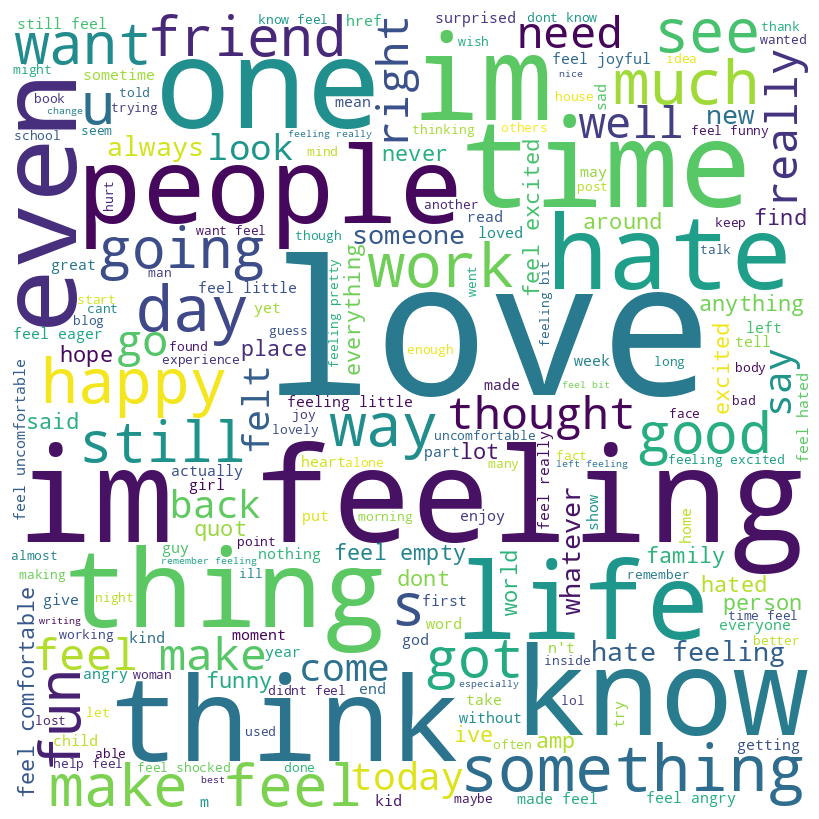

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all the lemmatized tokens into a single string
all_words = ' '.join(df['text_lemmatized'])

# Generate a word cloud image
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(all_words)

# Display the generated image:
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()